In [1]:
import glob

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import seaborn as sns

In [2]:
control_files = sorted(glob.glob('mx2t6_ecmwf_control-forecast_2025-01-??_AUS.grib'))

In [3]:
control_files

['mx2t6_ecmwf_control-forecast_2025-01-01_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-02_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-03_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-04_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-05_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-06_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-07_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-08_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-09_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-10_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-11_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-12_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-13_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-14_AUS.grib',
 'mx2t6_ecmwf_control-forecast_2025-01-15_AUS.grib']

In [4]:
ds_control = xr.open_mfdataset(control_files, engine='cfgrib')

Ignoring index file '/Users/irv033/Documents/code/ecmwf/mx2t6_ecmwf_control-forecast_2025-01-01_AUS.grib.5b7b6.idx' incompatible with GRIB file


In [5]:
ds_control

<xarray.Dataset> Size: 708MB
Dimensions:            (time: 30, step: 60, latitude: 277, longitude: 355)
Coordinates:
  * time               (time) datetime64[ns] 240B 2025-01-01 ... 2025-01-15T1...
  * step               (step) timedelta64[ns] 480B 0 days 06:00:00 ... 15 day...
  * latitude           (latitude) float64 2kB -10.0 -10.12 ... -44.38 -44.5
  * longitude          (longitude) float64 3kB 112.0 112.1 112.2 ... 156.1 156.2
    number             int64 8B 0
    heightAboveGround  float64 8B 2.0
    valid_time         (time, step) datetime64[ns] 14kB dask.array<chunksize=(2, 60), meta=np.ndarray>
Data variables:
    mx2t6              (time, step, latitude, longitude) float32 708MB dask.array<chunksize=(2, 60, 277, 355), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-05T09:43 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
ds_perturbed = xr.open_dataset('mx2t6_ecmwf_perturbed-forecast_2025-01-01_AUS.grib', engine='cfgrib')

In [7]:
ds_perturbed

<xarray.Dataset> Size: 2GB
Dimensions:            (number: 50, time: 2, step: 60, latitude: 277,
                        longitude: 355)
Coordinates:
  * number             (number) int64 400B 1 2 3 4 5 6 7 ... 45 46 47 48 49 50
  * time               (time) datetime64[ns] 16B 2025-01-01 2025-01-01T12:00:00
  * step               (step) timedelta64[ns] 480B 0 days 06:00:00 ... 15 day...
  * latitude           (latitude) float64 2kB -10.0 -10.12 ... -44.38 -44.5
  * longitude          (longitude) float64 3kB 112.0 112.1 112.2 ... 156.1 156.2
    heightAboveGround  float64 8B ...
    valid_time         (time, step) datetime64[ns] 960B ...
Data variables:
    mx2t6              (number, time, step, latitude, longitude) float32 2GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-05T09:43 GRIB to CDM+CF via cfgrib-0.9.1...

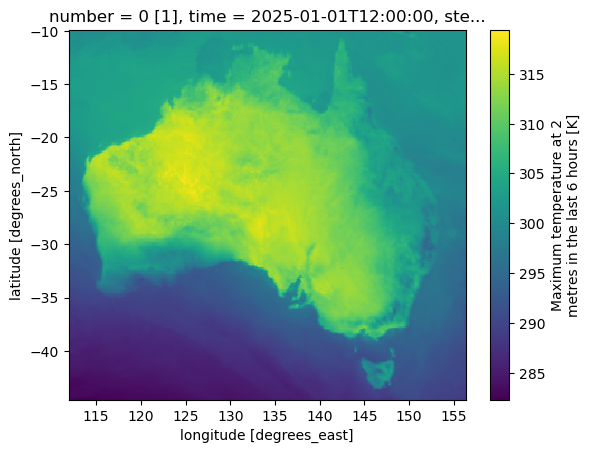

In [8]:
ds_control.isel({'time': 1, 'step': 10})['mx2t6'].plot()

In [9]:
ds_control_hobart = ds_control.sel({'latitude': -42.88, 'longitude': 147.32}, method='nearest')

In [10]:
ds_perturbed_hobart = ds_perturbed.sel({'latitude': -42.88, 'longitude': 147.32}, method='nearest')

Since the timezone for Hobart is GMT + 10, we need to add 10 hours to the time values. The mx2t6 variable is the maximum temperature from the preceeding 6 hours, so I then subtract 3 hours (i.e. so just + 7) to centre it.

The first forecast runs from 10am - 4pm local time, which means there isn't a full set of four six-hourly values for the first and last day of the forecast. I keep maximum value for the first day (because the daily maximum pretty much always occurs after 10am) but exclude the maximum value from the last day.

In [11]:
def extract_reality(da_control):
    """Extract reality"""

    da_control_stacked = da_control.isel(step=slice(0, 2)).stack({'date': ['time', 'step']})
    times = (da_control_stacked.step + da_control_stacked.time).values + np.timedelta64(7, 'h')
    values = da_control_stacked.values - 273.15
    df = pd.DataFrame(values, index=times, columns=['mx2t6'])
    df = df.resample('D').max()
    df = df[0:-1]

    return df
    

def extract_forecast(da):
    """Extract a single forecast."""

    times = (da.step + da.time).values + np.timedelta64(7, 'h')
    values = da.values - 273.15
    df = pd.DataFrame(values, index=times, columns=['mx2t6'])
    df = df.resample('D').max()
    df = df[0:-1]

    return df

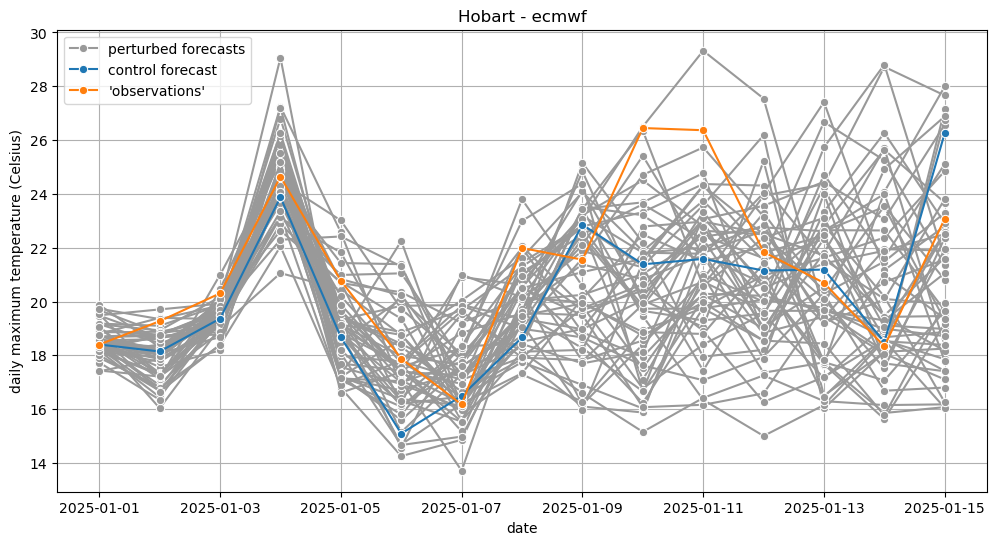

In [12]:
plt.figure(figsize=(12, 6))

n_members = len(ds_perturbed_hobart.number)
for member in range(n_members):
    df_perturbed = extract_forecast(ds_perturbed_hobart['mx2t6'].isel(time=0, number=member))
    label = 'perturbed forecasts' if member == 1 else None
    sns.lineplot(data=df_perturbed, x=df_perturbed.index, y='mx2t6', marker='o', color='0.6', label=label)

df_control = extract_forecast(ds_control_hobart['mx2t6'].isel(time=0))
sns.lineplot(data=df_control, x=df_control.index, y='mx2t6', marker='o', label='control forecast')

df_reality = extract_reality(ds_control_hobart['mx2t6'])
sns.lineplot(data=df_reality, x=df_reality.index, y='mx2t6', marker='o', label="""'observations'""")

plt.title('Hobart - ecmwf')
plt.xlabel('date')
plt.ylabel('daily maximum temperature (Celsius)')
plt.grid()
plt.show()